# Upstream bridge: from another tool's FASTA to a scikit-learn pipeline

Most AAanalysis work starts somewhere else. A homology search, a motif scanner, a
proteomics filter or a colleague's export hands you a **FASTA file** plus a label per
record, and the question is how to get from there to a model. This tutorial is that
recipe, end to end, in three hops:

1. **Read** the upstream file into a `df_seq` with `aa.read_fasta`.
2. **Adapt** the sequences into the part geometry CPP needs with `aa.SequenceFeature.get_df_parts`.
3. **Bridge** into a real `sklearn.pipeline.Pipeline` with `aa.SequenceFeatureTransformer`, so CPP feature selection happens *inside* cross-validation instead of before it.

Everything below runs offline on the bundled `DOM_GSEC` benchmark and needs no extra
package: `scikit-learn` is already a core dependency. Only **one** bridge is covered here,
the FASTA hand-off, because it is the one every tool can produce. The two heavy
representations, protein language model embeddings and AlphaFold-derived channels, have
their own bridge in the *Embeddings & AlphaFold* tutorial.

## 1. The hand-off: a FASTA file from an upstream tool

To keep the notebook self-contained, the "upstream tool" is simulated: a bundled dataset is
written out with `aa.to_fasta`, which is also the writer you use in the other direction, to
hand AAanalysis results to the next tool in your chain. Substitute your own file here and
the rest of the notebook is unchanged.

In [1]:
import os
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import aaanalysis as aa

aa.options["verbose"] = False

# Stand-in for the upstream tool: 40 gamma-secretase candidates written to a FASTA file,
# with the class label carried in the header (1 = substrate, 0 = non-substrate).
df_hits = aa.load_dataset(name="DOM_GSEC", n=20)
folder_upstream = tempfile.mkdtemp()
file_hits = os.path.join(folder_upstream, "upstream_hits.fasta")

aa.to_fasta(df_seq=df_hits[["entry", "sequence", "label"]], file_path=file_hits,
            col_id="entry", col_seq="sequence", sep="|", col_db=None, cols_info=["label"])

for line in open(file_hits).read().splitlines()[:4]:
    print(line if line.startswith(">") else line[:64] + " ...")

>Q14802|0
MQKVTLGLLVFLAGFPVLDANDLEDKNSPFYYDWHSLQVGGLICAGVLCAMGIIIVMSAKCKCK ...
>Q86UE4|0
MAARSWQDELAQQAEEGSARLREMLSVGLGFLRTELGLDLGLEPKRYPGWVILVGTGALGLLLL ...


The header convention is the only thing you have to match. `aa.read_fasta` splits each
header on `sep` and maps the pieces onto columns: `col_id` takes the first field, `col_db`
an optional leading database tag (as in `>sp|P12345|...`), and `cols_info` names whatever
follows. Here the single trailing field is the label.

In [2]:
df_seq = aa.read_fasta(file_path=file_hits, col_id="entry", col_seq="sequence",
                       sep="|", col_db=None, cols_info=["label"])

# Header fields arrive as strings; the label is the only one that has to be numeric.
df_seq["label"] = df_seq["label"].astype(int)
aa.display_df(df=df_seq, n_rows=10, show_shape=True)

DataFrame shape: (40, 3)


,entry,sequence,label
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0
6,P01135,MVPSAGQLALFALGI...LLKGRTACCHSETVV,0
7,O43914,MGGLEPCSRLLLLPL...SDVYSDLNTQRPYYK,0
8,P05556,MNLQPIFWIGLISSV...KSAVTTVVNPKYEGK,0
9,P16234,MGTSHPAFLVLGCLL...DIGIDSSDLVEDSFL,0
10,P50895,MEPPDAPAQARGAPR...SGGARGGSGGFGDEC,0


## 2. The adapter: sequences into CPP parts

CPP compares **parts** of a sequence, not whole sequences. `aa.SequenceFeature.get_df_parts`
is the adapter. When the upstream file carries domain boundaries (a `tmd_start` / `tmd_stop`
pair) it slices TMD, JMD-N and JMD-C. A plain FASTA has no such annotation, so it falls back
to a sequence-level geometry: the whole sequence as the target part plus its two flanks,
sized by `jmd_n_len` / `jmd_c_len`. That fallback is what makes an unannotated upstream file
usable at all.

In [3]:
sf = aa.SequenceFeature(verbose=False)
df_parts = sf.get_df_parts(df_seq=df_seq, list_parts=None, all_parts=False,
                           jmd_n_len=10, jmd_c_len=10, tmd_len=None,
                           remove_entries_with_gaps=False, replace_non_canonical_aa=False)

print("parts:", list(df_parts.columns))
aa.display_df(df=df_parts, n_rows=5, show_shape=True)

parts: ['tmd', 'jmd_n_tmd_n', 'tmd_c_jmd_c']
DataFrame shape: (40, 3)


,tmd,jmd_n_tmd_n,tmd_c_jmd_c
entry,,,
Q14802,FLAGFPVLDANDLED...CKFGQKSGHHPGETP,MQKVTLGLLVFLAGF...FYYDWHSLQVGGLIC,AGVLCAMGIIIVMSA...PGETPPLITPGSAQS
Q86UE4,AQQAEEGSARLREML...SQTKSETSWESPKQI,MAARSWQDELAQQAE...ENLTVNGGGWNEKSV,KLSSQISAGEEKWNS...SPKQIKKKKKARRET
Q969W9,AAAAAGQPNVSCTCN...HTHIAPLESAAIWSK,MHRLMGVNSTAAAAA...FHRFQPTYPYLQHEI,DLPPTISLSDGEEPP...AIWSKEKDKQKGHPL
P53801,PYWRLRLGGAALLLL...TRHDEIRKKYGLFKE,MAPGVARGPTPYWRL...PPASLCKLSSARWGV,CWVNFEALIITMSVV...GLFKEENPYARFENN
Q8IUW5,VLAAAVFVGGAVSSP...SVSGAETVNGEVPAT,MAPRALPGSAVLAAA...HYIMKNEANADVLKA,MVADNSLYDPESPVT...EVPATPVKRERSGTE


You can stop here and hand `df_parts` to `aa.CPP` yourself, which is what the
:class:`~aaanalysis.CPP` tutorial does. The rest of this notebook takes the other route and
lets the pipeline own that step.

## 3. The bridge: `SequenceFeatureTransformer` inside a real `Pipeline`

`aa.SequenceFeatureTransformer` wraps the whole `get_df_parts` to `aa.CPP.run` to
`feature_matrix` chain behind the scikit-learn `fit` / `transform` API. It takes the
`df_seq` **itself** as `X`, which is what makes it a drop-in first step: everything
downstream is stock scikit-learn.

That ordering is the point. Selecting CPP features once on the full labeled set and then
cross-validating the classifier lets every test fold influence which features exist, and
the score comes out optimistic. Inside a `Pipeline`, `fit` runs on the training fold only,
so each fold re-mines its own signature and the held-out proteins stay held out.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# X is the sequence table (the label column is deliberately NOT part of X); y the labels.
X_seq = df_seq[["entry", "sequence"]]
labels = df_seq["label"].to_numpy()

sft = aa.SequenceFeatureTransformer(
    split_kws=aa.SequenceFeature.get_split_kws(split_types=["Segment", "Pattern"]),
    df_scales=aa.load_scales(name="scales", top60_n=20),
    n_filter=25,
    label_test=1,
    label_ref=0,
    max_overlap=0.5,
    max_cor=0.5,
    simplify=False,
    n_jobs=1,
    random_state=0,
    verbose=False)

pipe = Pipeline([("sft", sft),
                 ("scaler", StandardScaler()),
                 ("clf", RandomForestClassifier(n_estimators=100, random_state=0))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(pipe, X_seq, labels, cv=cv, scoring="balanced_accuracy")

print("balanced accuracy per fold:", np.round(scores, 3))
print(f"mean: {scores.mean():.3f}")

balanced accuracy per fold: [0.5   0.75  0.875 0.875 0.625]
mean: 0.725


Forty proteins across five folds is a small-N estimate and the fold spread shows it. Read
the mean as a sanity check that the bridge carries signal, not as a performance claim. The
*P10: Validation* protocol covers how to report such a number honestly.

## 4. Interpretability survives the bridge

A wrapped estimator usually costs you the column names. This one does not:
`get_feature_names_out` returns the selected CPP feature ids, so every column of the matrix
the classifier saw is still a readable `PART-SPLIT-SCALE` statement, and the fitted
transformer keeps the full `df_feat` next to it.

In [5]:
pipe.fit(X_seq, labels)
sft_fitted = pipe.named_steps["sft"]

feature_names = sft_fitted.get_feature_names_out(input_features=None)
print("selected features:", len(feature_names))
print("first three:", list(feature_names[:3]))

aa.display_df(df=sft_fitted.df_feat_, n_rows=10, show_shape=True)

selected features: 25
first three: ['JMD_N_TMD_N-Pattern(C,4,8,12)-TANS770102', 'TMD_C_JMD_C-Pattern(C,2,5,9,12)-OOBM850101', 'JMD_N_TMD_N-Pattern(C,1,5,8)-RICJ880117']
DataFrame shape: (25, 13)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
1,"JMD_N_TMD_N-Pat...,12)-TANS770102",Conformation,"α-helix (C-term, out)","α-helix (C-terminal, outside)","Normalized freq...Scheraga, 1977)",0.387000,0.177000,0.177000,0.110000,0.085000,0.000028,0.037155,"9,13,17"
2,"TMD_C_JMD_C-Pat...,12)-OOBM850101",Structure-Activity,Stability,Stability (extended-coil),"Optimized beta-...e et al., 1985)",0.370000,0.128000,-0.128000,0.083000,0.079000,0.000062,0.037155,"29,32,36,39"
3,"JMD_N_TMD_N-Pat...5,8)-RICJ880117",Conformation,Unclassified (Conformation),"α-helix (C-terminal, outside)","Relative prefer...chardson, 1988)",0.363000,0.117000,0.117000,0.082000,0.073000,0.000088,0.037155,"13,16,20"
4,"JMD_N_TMD_N-Pat...5,8)-FASG760105",Polarity,Unclassified (Polarity),pK-C,"pK-C (Fasman, 1976)",0.355000,0.253000,-0.253000,0.188000,0.169000,0.000122,0.037155,"13,16"
5,"JMD_N_TMD_N-Seg...,12)-DAYM780201",Others,Mutability,Mutability,"Relative mutabi... et al., 1978b)",0.355000,0.087000,0.087000,0.047000,0.073000,0.000122,0.037155,"2,3"
6,"JMD_N_TMD_N-Seg...,12)-QIAN880128",Conformation,Coil (N-term),Coil (N-terminal),"Weights for coi...ejnowski, 1988)",0.355000,0.083000,-0.083000,0.037000,0.067000,0.000122,0.037155,"2,3"
7,"TMD_C_JMD_C-Pat...,12)-OOBM850104",Polarity,Hydrophilicity,Non-bonded energy per atom,"Optimized avera...e et al., 1985)",0.353000,0.123000,0.123000,0.089000,0.084000,0.000137,0.037155,"29,32,36,40"
8,"TMD_C_JMD_C-Pat...5,9)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.344000,0.105000,0.105000,0.079000,0.064000,0.000200,0.040710,"32,36,39"
9,"TMD_C_JMD_C-Pat...4,7)-TANS770102",Conformation,"α-helix (C-term, out)","α-helix (C-terminal, outside)","Normalized freq...Scheraga, 1977)",0.335000,0.171000,0.171000,0.127000,0.130000,0.000289,0.043682,"21,24,27"
10,"TMD_C_JMD_C-Pat...5,9)-SUEM840102",Structure-Activity,Unclassified (S...cture-Activity),Stability (extended-coil),"Zimm-Bragg para...i et al., 1984)",0.332000,0.183000,0.183000,0.145000,0.117000,0.000321,0.046753,"32,36,40"


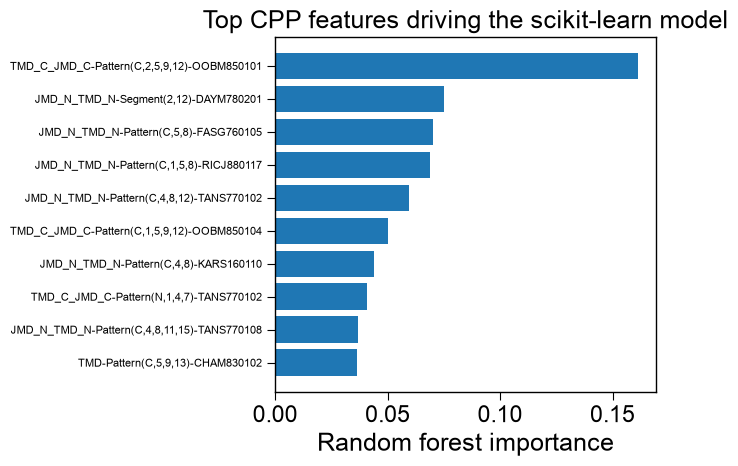

In [6]:
aa.plot_settings()

importances = pipe.named_steps["clf"].feature_importances_
order = np.argsort(importances)[-10:]
color = aa.plot_get_clist(n_colors=2)[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(np.arange(len(order)), importances[order], color=color)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
ax.set_xlabel("Random forest importance")
ax.set_title("Top CPP features driving the scikit-learn model")
plt.tight_layout()
plt.show()

## 5. Scoring the next delivery from the same tool

The fitted pipeline is now a predictor for anything that tool sends next. A new FASTA goes
through exactly the same two calls, and `transform` encodes it with the features chosen at
`fit` time, so the new matrix is column-compatible by construction.

In [7]:
# A second, unlabeled delivery: six proteins the pipeline has never seen.
df_all = aa.load_dataset(name="DOM_GSEC")
df_batch2 = df_all[~df_all["entry"].isin(df_seq["entry"])].head(6)

file_batch2 = os.path.join(folder_upstream, "upstream_batch2.fasta")
aa.to_fasta(df_seq=df_batch2[["entry", "sequence"]], file_path=file_batch2,
            col_id="entry", col_seq="sequence", sep="|", col_db=None, cols_info=None)

df_new = aa.read_fasta(file_path=file_batch2, col_id="entry", col_seq="sequence",
                       sep="|", col_db=None, cols_info=None)

X_new = sft_fitted.transform(X=df_new)
df_X_new = pd.DataFrame(X_new, columns=feature_names)
df_X_new.insert(0, "entry", df_new["entry"].to_numpy())

print("feature matrix:", X_new.shape)
aa.display_df(df=df_X_new, n_rows=10, n_cols=5, show_shape=True)

feature matrix: (6, 25)
DataFrame shape: (6, 26)


,entry,"JMD_N_TMD_N-Pattern(C,4,8,12)-TANS770102","TMD_C_JMD_C-Pattern(C,2,5,9,12)-OOBM850101","JMD_N_TMD_N-Pattern(C,1,5,8)-RICJ880117","JMD_N_TMD_N-Pattern(C,5,8)-FASG760105"
1,Q15303,0.956670,0.581000,0.469000,0.221500
2,P16882,0.565670,0.634750,0.345670,0.491500
3,P04439,0.877670,0.526500,0.296000,0.229500
4,P08069,0.532330,0.663750,0.605000,0.664000
5,P27930,0.440330,0.521000,0.246670,0.442500
6,Q9Y219,0.717330,0.602250,0.370330,0.369000


In [8]:
df_pred = pd.DataFrame({"entry": df_new["entry"],
                        "predicted_label": pipe.predict(df_new),
                        "p_substrate": pipe.predict_proba(df_new)[:, 1].round(3)})
aa.display_df(df=df_pred, n_rows=10, show_shape=True)

DataFrame shape: (6, 3)


,entry,predicted_label,p_substrate
1,Q15303,1,0.760000
2,P16882,1,0.690000
3,P04439,1,0.680000
4,P08069,0,0.480000
5,P27930,0,0.390000
6,Q9Y219,1,0.580000


## 6. Recap: the bridge in four lines

Stripped of the narrative, the whole recipe is:

```python
df_seq = aa.read_fasta(file_path="hits.fasta", cols_info=["label"])          # 1. read
pipe = Pipeline([("sft", aa.SequenceFeatureTransformer(random_state=0)),      # 2. bridge
                 ("scaler", StandardScaler()),
                 ("clf", RandomForestClassifier(random_state=0))])
pipe.fit(df_seq[["entry", "sequence"]], df_seq["label"].astype(int))          # 3. fit
pipe.predict(df_new)                                                          # 4. predict
```

What to change for your own data:

- **Header convention**: `sep`, `col_db` and `cols_info` in `aa.read_fasta` cover the usual
  UniProt-style and tool-specific formats.
- **Domain boundaries**: if your upstream file has them, keep the `tmd_start` / `tmd_stop`
  columns on the `df_seq` and `aa.SequenceFeature.get_df_parts` will slice real parts
  instead of the sequence-level fallback, which is normally the stronger signal.
- **Selection budget**: `n_filter`, `max_cor` and `max_overlap` trade feature count against
  redundancy; `split_kws` and `df_scales` set how wide CPP searches, and are the two levers
  that dominate runtime.

Where to go next: the :class:`~aaanalysis.CPP` tutorial for the feature engineering itself,
the *Embeddings & AlphaFold* tutorial for the embedding and structure bridges, and the
*P8: Prediction* protocol for the full prediction workflow this recipe feeds.